In [ ]:
Content
1. Networking and Communication
    1. What is Networking
    2. Understanding IP Addresses
    3. How DNS Works
    4. Client-Server Model Explained
    5. Forward Proxy vs. Reverse Proxy
    6. Introduction to Load Balancing
    7. What is an API Gateway?
    8. Content Delivery Networks (CDN) in System Design
2. Protocols
    1. TCP & UDP - Understanding the Basics
    2. HTTP - The Backbone of the Web
    3. REST & RESTfulness - API Design Principles
    4. Real-Time Communication Protocols
    5. Modern APl Protocols - Beyond REST

In [ ]:
# Topic to be covered
Authentication/Authorization

# 1. Networking and Communication

In [ ]:
Networking is the backbone of the system design, as all systems are distributed, and components communicate over a network. — understanding networking ensures your system is reliable, scalable, and fast.


🔗 Why Networking is Important in System Design

1. Communication Between Services
	•	Microservices, frontend-backend, database, cache, etc., all talk via network protocols (usually HTTP, gRPC, TCP).
	•	Understanding request/response cycles, latency, and timeouts is key.

2. Scalability
	•	Load balancers and reverse proxies (like NGINX, AWS ELB) use networking to distribute traffic.
	•	Horizontal scaling involves adding networked nodes (not just CPU/memory).

3. Latency and Bandwidth Management
	•	Good system design minimizes latency (time to respond) and optimizes bandwidth (data throughput).
	•	Networking concepts like CDN, edge caching, and compression become vital.

4. Reliability & Fault Tolerance
	•	Redundancy, failover, retries, timeouts, and circuit breakers depend on network behavior.
	•	Understanding DNS, heartbeat protocols, and TCP retries helps design resilient systems.

5. Security
	•	Securing communication between systems (e.g., via HTTPS, mTLS, firewalls, VPNs) requires networking knowledge.

6. API Design & Protocols
	•	Designing RESTful APIs, WebSockets, or gRPC requires understanding HTTP headers, methods, and status codes.


In [ ]:
# Questions to be covered
    -   “What happens when you type a URL in the browser?”
	•	“How would you reduce latency between services?”
	•	“How does DNS work in your system?”
	•	“What is the difference between HTTP 1.1 and HTTP/2?”


In [ ]:
# IP Address
 - IP Address are unique numeric numbers assigned to every device connected over a network. Just like as your home address.
 - Enable to locate on the network (provides the device’s location on the network)
 - Two Types
    - IPv4: 
        - Ex: Decimal, dot-separated (e.g. 192.168.1.1)
        - Total no. of addresses: ~4.3 billion addresses (2³²)
        - Size: 32 bits       => 4 octets × 8 bits or 1 byte = 32 bits # A.B.C.D each letter is on octets
           - Each octet can have any value from 0 to 255, and its binary representation is 2^8 for each octect, so 4 octects * (2^8) for each octect
        

   - IPv6:
      - Ex: 001:0db8:85a3:0000:0000:8a2e:0370:7334
      - Total no. of addresses: ~340 undecillion addresses (2¹²⁸)
      - Size: 128 bits  => IPv6 is made up of 8 groups of 4 hexadecimal digits.
         - Each hexadecimal takes 4 bits of space, so 4 * 8 * 4 = 128 bits
         - Ex: F is one hexadecimal letter, and its binary representation is 1111, that why it takes 2^4 (4 bits) of space.


- Public vs Private
  Internet provide assign a public IP to the router, then each system connected to the network has a private IP (Its like house number in the building). 
  - Public
    - Assigned by ISP, its unique worldwide and used to communicate over the internet.
  - Private
    - Used within the local network (home, LAN, enterprise).
    - Can not be accessed from the internet.
    - Ex: 192.168.0.1    
    - Private IPs are used for devices inside local networks (like your home, office, or data center). 
      They are not routable on the internet and are reserved specifically for internal communication.
    - Security: Devices with private IPs are isolated from direct internet access.
    - System design Scalability and Load Balancing: Use IP based routing. A load balancer uses private IPs to distribute traffic to backend servers                                                                          
    - Router Working
      1. NAT Technology: Router translates the private IP to its public IP. Adds a unique port number to identify which laptop sent the request                                                                           
      2. NAT allows sharing public IP within the router among all devices connected to it.
      3. Steps:
          - Laptop A and B connected with the same router. Laptop A has a private IP and port (50000)
          - Router converts the private IP to public IP (103.25.69.170:40001 → 192.168.0.2:50000) and manintain this table.
          - Request sent to google with (103.25.69.170:40001) as source and google replies on the same IP with the port number. and then router convet it in the reverse direction.                                                                         

                 🌐 Internet
                     |
            Public IP (e.g., 203.0.113.10)
                     |
               [ Load Balancer ]
                     |
      ┌──────────────┼──────────────┐
      |              |              |
192.168.1.10   192.168.1.11   192.168.1.12
 App Server A   App Server B   App Server C                                         

In [3]:
# What happens when you type a URL in browser?
Step 1: DNS lookup (Goal: Convert domain name → IP address)
DNS
    - It is the phonebook of the internet
    - Translate human readable domain names to IP address.

┌──────────────┐
│  1. Browser  │ 🔁 Has it in memory cache?
└─────┬────────┘
      ↓ No
┌──────────────┐
│  2. OS Cache │ 🔁 OS DNS cache (Windows/Linux/macOS)
└─────┬────────┘
      ↓ No
┌────────────────────────────┐
│  3. Router/Modem Cache     │ 🔁 Your home router DNS cache
└─────┬──────────────────────┘
      ↓ No
┌────────────────────────────┐
│  4. ISP DNS Resolver       │ 🧠 Big DNS resolver (Jio, Airtel, etc.)
│     → Checks its own cache │
└─────┬──────────────────────┘
      ↓ No
┌─────────────────────────────────────┐
│  5. Recursive DNS Lookup begins     │
│                                     │
│  a. Root DNS Server (.com?)         │
│  b. TLD Server (example.com?)       │
│  c. Authoritative Server (has IP)   │
└─────────────────────────────────────┘

Recursive DNS Resolver (e.g., 8.8.8.8)
        ↓
        a. Root DNS Server            → "I don't know www.example.com, but I know who handles .com"
        ↓
        b. TLD Server for .com        → "I don't know www.example.com, but I know who owns example.com"
        ↓
        c. Authoritative Server       → "Yes, here's the IP for www.example.com → 93.184.216.34" (owned by Owned by the domain administrator and managed by Godaddy)
        ↓
        Resolver sends IP address back to your browser

- recursive resolver does all the heavy lifting 
- When the recursive resolver finally gets to the authortative server, this server replies with the final IP address. It has all the IP mappings.



Step 2: TCP Handshake (to port 443)
  - Establish TCP connection, at Transport layer (Layer 4)
  - Before data can be exchanged, a reliable connection must be established between client and server. TCP does this using a 3-step handshake: SYN → SYN-ACK → ACK 
  - No encryption
Client                    Server
  |                         |
  | --- SYN (seq=x) ------> |  ➤ "Hey! I want to start a connection."
  |                         |
  | <-- SYN-ACK (seq=y,    |  ➤ "Sure! Let's do it. Acknowledging yours (x+1), and here's mine (y)."
  |       ack=x+1)          |
  |                         |
  | --- ACK (ack=y+1) ----> |  ➤ "Cool! Acknowledging your sequence. We're connected!"
  |                         |

Step 3: TLS/SSL Handshake (Creating the Secure Channel)
  - Once TCP connection is done, TLS ensures encryption, integrity, and authentication before actual data (like passwords or HTML) is exchanged.
  - It secures the connection. It involves certificates, key exchange.
  - ClientHello → ServerHello + Certificate → Key Exchange → Session Key Established
  - Working
    1.  Client verifies server’s identity via certificate
	2.	Both generate same “session key” using shared secret (derived from Ra, Rb, and pre-master secret)
	3.	All further communication is: Encrypted with session key (symmetric encryption)

Step 4: HTTP request
  - Encrypted using the TLS session key.

Step 5: Server Responds & Page Renders
  - Server sends back an HTTP Response:
  - Browser starts rendering HTML page, it download images from CDN, execute scripts and render DOM

Step 6: (optional)
  - Server may connect with 3rd party server, or a Database.


In [ ]:
# FAQs
1. DNS-based load balancing?
  - DNS-based load balancing distributes traffic across multiple servers or data centers by mapping a single domain (like www.example.com) to multiple IP addresses.
  - One domain is mapped with multiple IPs.
  - So traffic can be distributed by Geolocation, Server health, or pre-configured weight distribution.

In [ ]:
# Client Server Model
  Components:
  1. Client: User facing application app/ website.
  2. Server: Web server
  3. Network: Internet, LAN

# Type of Communication
 1. Request/Response model: for Transactional (HTTP)
 2. Persistance connection for real time comunication: web socket, FTP session.

# Statless vs Statefull
- Stateless
 - No memory of past interactions, each request is treated independently.
 - Working
   - Session token (like a JWT) is stored on the client (browser) and sent with every request.
   - Server does not store any session, it just verifies the token on each request.
   - Server holds no session for a user.
 - Benefits: Scalability, Easy caching, load balancing
 - Best for Rest APIs

- Statefull
  - Session token (e.g., session_id) is stored on the server in memory or Redis. 
  - Maintain session information accross all requests. Remembers previous interactions with the client (session data, user context, etc.)
  - Working
    - You log in once → server creates a session and stores it in memory.
	- Client gets a cookie with session_id
    - On next request, server looks up session info using that ID
       
  - Best for Websocket, multi-player games 

Note: REST APIs are ideally should be stateless — each request should be independent and self-contained. If the server stores session data between requests, it’s technically stateful and not RESTful in the pure sense.       

In [ ]:
# Forward vs Reverse Proxy
1. Forward Proxy
    - [Browser] → [Forward Proxy] → [Google.com]
    - A middleman between the client and the internet. The client sends requests to the proxy, which forwards them to the destination.
    - It protects/ benefits the client.
    - Usecase:
        - Caching content to reduce bandwidth
        - Hiding client identity/IP
        - Filtering content (e.g., parental controls)
        - Accessing geo-restricted content (VPNs are forward proxies)
        - Logging outbound traffic

2. Reverse Proxy
    - A middleman between the client and a group of servers. Client thinks it’s talking to one server, but the reverse proxy routes the request to the correct backend.
    - It protects/ benefits the server.
    - Nginx reverse proxy handles traffic for 3 servers. Client → Nginx → Server1 / Server2 / Server3         
    - Usecase for Server:
        - 	Load balancing traffic across servers
    	-	SSL termination (handle HTTPS at the proxy), means the reverse proxy (e.g., Nginx) handles the decryption of HTTPS and then sends a HTTP request to server.
    	-	Caching static content (images, scripts)
    	-	Security: hides backend IPs from the internet
    	-	Rate limiting, firewall, WAF

In [ ]:
# Load Balancer
    - A Load Balancer is like a smart traffic cop. It distributes incoming network traffic across multiple backend servers to ensure no single server is overwhelmed.
    - Usecase
        ✅ Scalability: Allows your system to handle more users by adding more servers
        ✅ High availability and reliability: If one server goes down, others can take over
        ✅ Performance: Distributes traffic evenly → faster response times
        ✅ Redundancy & Fault Tolerance: No single point of failure
        ✅ Health Monitoring: It can auto-remove unresponsive servers
        ✅ Security:
            - SSL Termination:Can offload SSL/TLS decryption from backend servers 
            - DDOS protection: Can detect and filter excessive or suspicious traffic before it hits servers.
            - Hides internal servers
            - Web Application Firewall: Can block malacious payloads
            - Rate limiting & throttling (to limit number of request per sec/minute/hr)
    
    


    
    - Types of Balancing (Static/Dynamic)
        1. Static Round Robin: Rotates between servers. Even distribution, simple APIs
        2. Static Least Connections: Chooses server with fewest active connections. Useful for chat or WebSocket apps
        3. Static IP Hash: Same client IP → same server. Sticky sessions
        4. Random: Randomly picks a server. Good for simple load distribution
        5. Dynamic Weighted: Sends more requests to stronger servers. If servers differ in capacity
        6. Dynamic Least Response time and Adaptive load balancing (checks load on server in real time)

### Based on Layer:
 - Layer 4 Load Balancer Example (TCP/UDP-based)
        - Operates at TCP/UDP level, it distribute requests based on network level data.
        - Example: You have 3 game servers running UDP on port 5000. It Distribute player traffic evenly among the 3 servers without knowing the content or url.
        - These are much faster.
        - This can route traffic by client IP and port.

- Layer 7 Load Balancer Example (HTTP-based)
        - It operates Http(s) level, and make routing decision based on content.
        - Example: A reverse proxy handles a website with /api and /login routes.
            [Client] ──HTTP/HTTPS─► [L7 Load Balancer]
                                   ├── /api ───► [API Server]
                                   └── /login ─► [Auth Server]

### Based on Deployment
1. Software based: Ngnix
2. Cloud based Load balance: AWS elastic load balancer, managed by them.
3. Independent hardware for enterprise level companies.    

    

In [ ]:
# API Gateway
    - An API Gateway is a server or service that acts as a single entry point for all client requests to backend services or APIs.
    - It removes the need of reverse proxy, as it already has all the functionality.
    - Usecase
        ✅ Single entry point: All APIs accessed via 1 domain (e.g., api.myapp.com)
        ✅ Rate limiting / throttling: 
            - Rate Limiting: Restrict the number of API calls by per user/IP per minute/hr/second.
                - Example: Max 100 requests per minute. Request 101 → HTTP error 429 Too Many Requests
            - Throttling:
                - mainly to control traffic during peak hr to avoid system crash.
                - Requests may be delayed or queued, not necessarily rejected.
                - Allow 10 requests/second, User sends 50 in 1 sec → 10 are served, 40 are queued/delayed    

        ✅ Version management: Route /v1/users to v1, /v2/users to v2
        ✅ Request transformation: Modify headers, URL paths, or payloads
        ✅ Caching: Speeds up repeated requests
        ✅ Logging/Monitoring: Centralized request logs and metrics. How APIs are performing.
        ✅ HTTPS enforcement & SSL termination: Encrypt/decrypt at the gateway
        ✅ Routing (URL based Load balancing): Distributes traffic to multiple backend services
            - It can route based on request method (GET/POST), url path (/user, /order), version (v1/v2), based on Headers
        ✅ Security: 
            - Authentication/Authorization: Validates tokens, handles OAuth, API keys
            - Hide internal server IPs 
            - Handle SSL termination
            - prevent from DDOS attack.
            - Bot/ abuse protection by rate limiting.
        ✅ API Composition and Aggregation:
            - API Gateways can combine multiple API calls into a single request.
            - Useful for microservices architecture where one client request may need data from multiple services.
            - Example:
                - Instead of calling /user, /orders, and /cart separately,
                - API Gateway calls all 3 services internally and returns a single response. 
 

# API Gateway without load balancer (routing based on URL)
Client → 🔐 API Gateway
             ↓
   ┌──────────────┬──────────────┬──────────────┐
   │ Auth Service │ User Service │ Order Service│ ...
   └──────────────┴──────────────┴──────────────┘

# API Gateway with load balancer (routing based on URL server health)
[Client]
   ↓
[AWS API Gateway] — Authentication, Url based Routing, Rate Limiting, SSL, etc.
   ↓
[Application Load Balancer (ALB)] — Load distribution, health checks
   ↓
[EC2 / ECS / Lambda / Fargate Services]


In [ ]:
# Why do we need a load balancer, even after a API gateway.

# Limitations of API gateway
    - API Gateway can do basic load routing between endpoints, but it doesn’t monitor instance load or health. For robust, dynamic, real-time load distribution, we use a dedicated load balancer like along with API Gateway
    - No real-time traffic distribution
    - No health checks
    - No IP hash routing: Require for session-sensitive services
    - API gateway only works for HTTP/TCP traffic, non-HTTP can not be served by api gateway
    - Limited control over backend connection management.
    - Can not work at layer 4 and 7 of network.
        






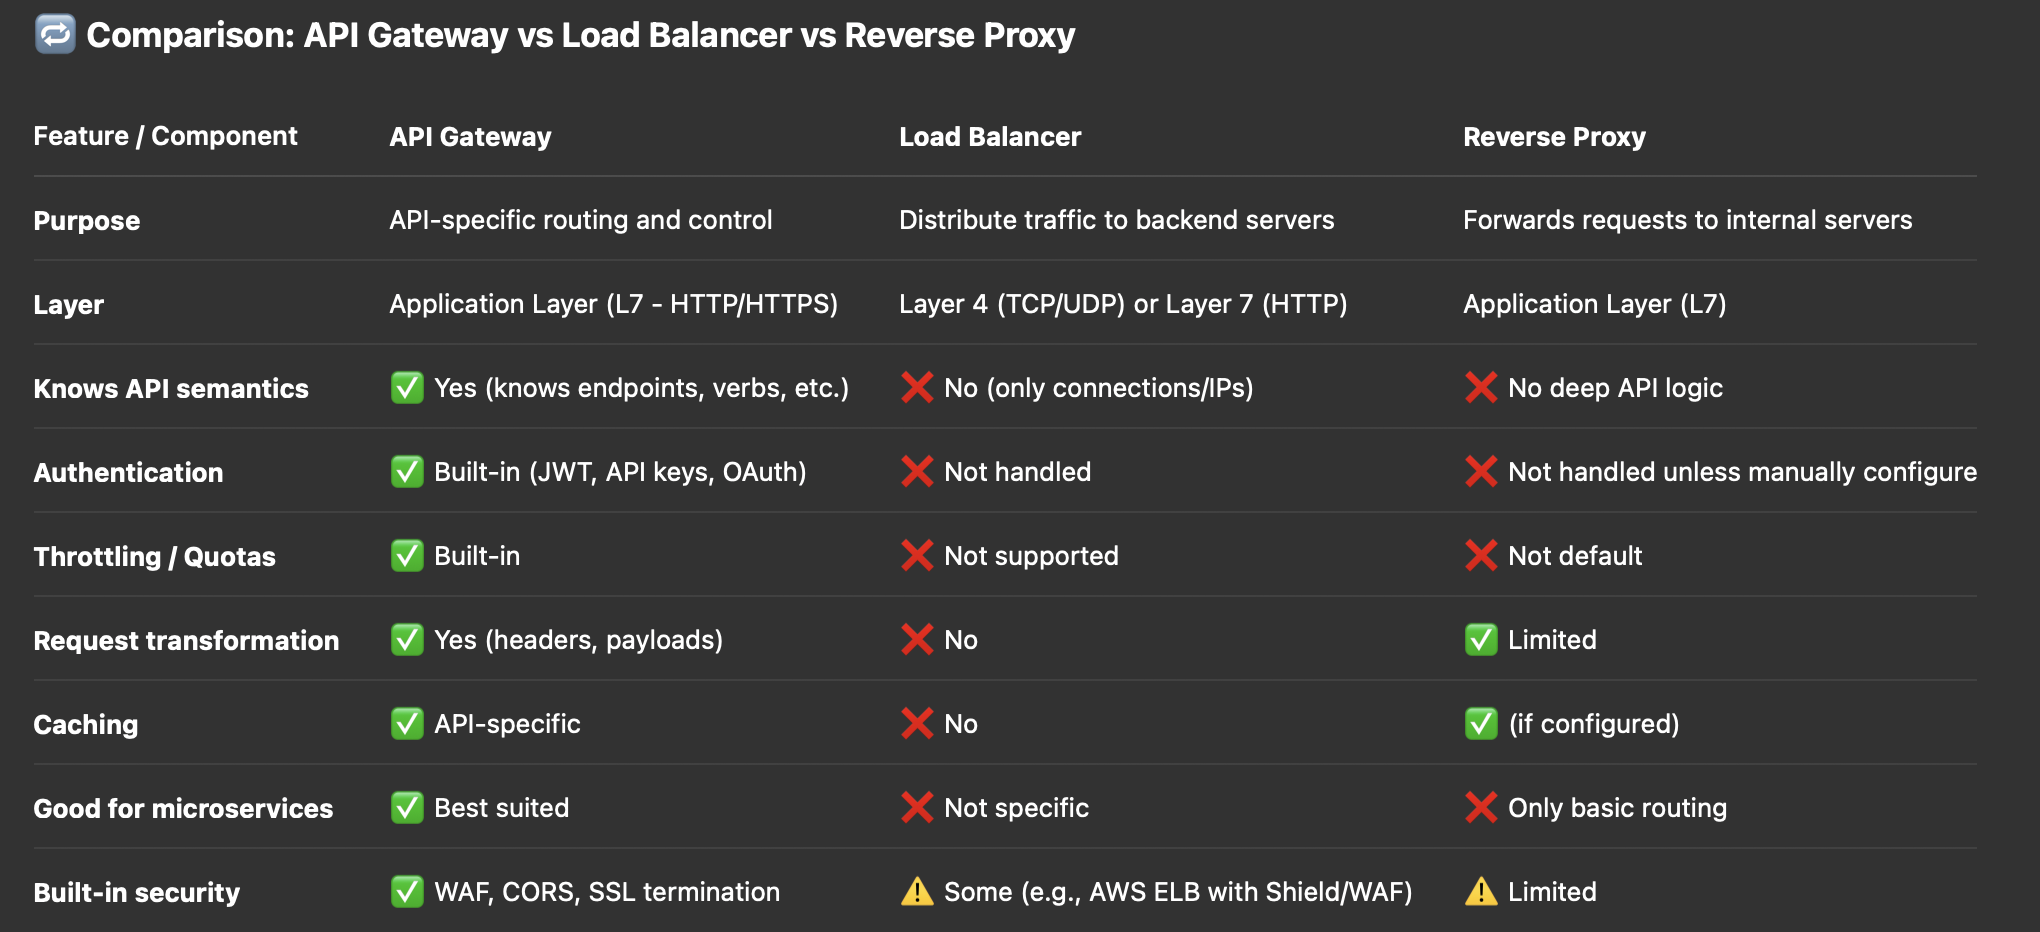

In [ ]:
# Content Delivery Network (CDN)
    - It is a globally distributed network of servers designed to Serve cached static content (like images, CSS, JavaScript, videos)  from the geological closest server  to the user.
    - The first time, the CDN fetches content from the origin. Then it caches that content so other nearby users get it instantly.
    - Benefits:
        1. Reduce latency: Serve content from a nearby location, not a distant origin server
        2. Improve performance: Faster load times = better user experience
        3. Reduce origin server load: Offloads repeated content requests from your main server
        4. Handle traffic spikes: CDNs are built to scale — they can absorb millions of users
        5. Increase availability: Content is served even if the origin server goes down (for a while)
        6. Security: Protects against DDoS attacks, bots, and SSL termination
        7. Improve load handling
        8. Data Compression and optimization: like gzip, reducing file size for faster delivery. 
        9. Cache expiry, Time to Live before cache expiry.
        10. Cache Invalidation: purge the cache content.

- CDN: The whole network of globally distributed servers (edge locations)
- Edge Server: An individual server in that CDN network

# How CDN works
1. User requests content (e.g., website, video, AP| data).
2. CDN directs the request to the nearest edge server based on geographic location, network latency, and server load.
3. Cache Hit: If the content is available on the edge server, it is delivered instantly.
4. Cache Miss: If the content is not cached, the request is forwarded to the origin server, fetched, and stored at the edge server for future use.
                  
# Request flow
[User Requests Content]
           |
           v
     [CDN Routes Request]
        /           \
  [Cache Hit]     [Cache Miss]
      |                 |
      v                 v
[Deliver from      [Forward to
 Edge Server]      Origin Server]
                        |
                        v
           [Fetch Content from Origin]
                        |
                        v
       [Store Content in Edge Server Cache]
                        |
                        v
         [Deliver Content from Edge Server]


# DNS lookup for CDN
- the CDN provider’s DNS system (like Cloudflare, Akamai, AWS CloudFront, etc.) returns the IP address of the geological closest or best-performing edge server.

[Browser] 
   │
   ▼
DNS Lookup (cdn.example.com) → Routed to Edge Server
   │
   ▼
[Edge Server]
 ├─ If Cache Hit  → Serve content
 └─ If Cache Miss → Fetch from Origin → Store in cache → Serve


# How CDN verify if user is authenticated
1. Signed URLs (with JWT or HMAC token)
    - Signed url: Url with a cryptographic token (ex: https://cdn.example.com/video.mp4?token=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9...)
    - Steps:
        - User logged in, backend server generates a signed URL and fronend stores it.
        - CDN server, just verify if JWT token is valid or not.
        - Frontend, in Js checks expiry in every few minute (like 4 min), and before the token expire the frontend sends a request to refresh the token and gets a new token from the server.



In [ ]:
# Other terms
1. SSL Termination 
    - HTTPS → HTTP at proxy/load balancer
    - SSL termination is the process of decrypting HTTPS (SSL/TLS) traffic at a proxy or load balancer before it reaches the backend servers.
2. SSL Passthrough
    - HTTPS stays encrypted until it reaches the backend (no termination)

#HTTPS
HTTPS = HTTP + TLS
	- HTTPS encrypts the HTTP traffic using TLS (formerly SSL)
	- Ensures confidentiality, integrity (data has not been altered during transmission), authenticity (authentic resource)
    - works on 443 port, instead of 80 (http)


# 2. Protocols

In [ ]:
# TCP and UDP Protocols
- Both are transport layer protocols (Layer 4 in the OSI model) used to send data over the Internet.
1. TCP (Transmission Control Protocol)
    - Connection-based: Needs a 3-way handshake (SYN, SYN-ACK, ACK) to start
    ✅ Reliable, Connection-Oriented, and Ordered
    - Slower (due to error checking and re-transmission)
    - Features
        - Reliable: Guarantees delivery of all packets, no loss. If a packet is lost TCP request the packet automatically.
        - Ordered: Delivers data in the same order as sent
        - Error-checking: Retransmits if a packet is lost
        - Flow control: Prevents overwhelming the receiver
    - Example:
        - Web (HTTP/HTTPS) – loading websites, Email (SMTP, IMAP), File Transfer (FTP, SFTP), Remote Access (SSH)
[Sender]                                  [Receiver]
   |                                          |
   | ----------- SYN -----------------------> |   (Step 1: Client → Server)
   |                                          |
   | <-------- SYN + ACK -------------------- |   (Step 2: Server → Client)
   |                                          |
   | ----------- ACK -----------------------> |   (Step 3: Client → Server)
   |                                          |
   | ----> Reliable Data Transfer Begins ---- |



2. UDP (User Datagram Protocol)
    - No handshake, Sends data immediately — no setup required
    ⚡ Fast, Connectionless, and Unreliable
    - Connectionless protocol: There is no need to establish a connection before sending the data.
    - No retransmission of lost packets.
    - Features
        - Unreliable: No guarantee of delivery
        - Out-of-order: May arrive out of order (or not at all)
        - Lightweight: No extra overhead
    - Example:
        - Live video/audio streaming (Zoom, YouTube Live), Online gaming, whatsapp call.
    - How zoom/ youtube applications are built
        - Loss-Tolerant Media Encoding: These codecs can tolerate a few lost packets without ruining the whole stream. 
            Even if 1-2 packet are lost Video may blur slightly, but it doesn’t freeze. Audio might skip slightly, but conversation continues.
        - Some packets can be reconstructed at the client side.
    - Analogy: Throwing a lot of postcards at delivery location, without even verifying if they are delivered or not.


[Sender]                                  [Receiver]
   |                                          |
   | ----------- REQUEST ------------------> |   (No handshake)
   |                                          |
   | <--------- RESPONSE 1 ------------------ |   (Can be out of order)
   | <--------- RESPONSE 2 ------------------ |   (No guarantee of delivery)
   | <--------- RESPONSE 3 ------------------ |   (No retransmission)

        

### 🔁 TCP vs UDP Comparison Table

| Feature           | TCP (Transmission Control Protocol)                         | UDP (User Datagram Protocol)                            |
|------------------|-------------------------------------------------------------|----------------------------------------------------------|
| **Reliability**   | ✅ Reliable (ensures data delivery)                         | ❌ Unreliable (no guarantee of delivery)                 |
| **Speed**         | 🕒 Slower (due to error checking & retransmission)          | ⚡ Faster (no retransmission overhead)                   |
| **Connection**    | 🔗 Connection-oriented (requires handshake)                 | 🔄 Connectionless (no setup before data transfer)        |
| **Ordering**      | ✅ Packets arrive in order                                  | ❌ No guarantee of order                                 |
| **Error Handling**| ✅ Error checking & retransmission                          | ❌ Minimal error checking, no retransmission             |
| **Overhead**      | 📦 High (due to handshake, sequencing, tracking)            | 🧾 Low (minimal protocol overhead)                       |
| **Use Cases**     | 🌐 Web, 📁 FTP/SFTP, ✉️ Email, 💾 DB access                  | 📺 Streaming, 🎮 Gaming, 📞 VoIP, 🧭 DNS lookups          |

In [ ]:
# HTTP
- HyperText Transfer Protocol is an application layer protocol used for communication between clients (browsers) and servers.

1. Client-Server Model:
    - Client (browser or mobile app) makes an HTTP request. Server (web server, APl, etc.) processes the request and sends back a response
2. Components of an HTTP Request:
    - Method: Defines the action (GET, POST, etc.)
        - PUT (Replace the object): Update an existing resource
        - PATCH (Partial Update): Partially update an existing resource.
                                                                    
    - URL
    - Headers: Metadata (content-type)
    - Body (optional): Data sent in POST/PUT requests

3. Components of an HTTP Response:
    - Status Code: Indicates success or failure (e.g., 200 OK, 404 Not Found)
        - 1xx: Informational status code.
        - 2xx: Success. 200 OK, 201 Resource Created
        - 3xx: Redirection. Resource moved permanently
        - 4xx: Client Error. 400 Bad Request, 401 Unauthorized, 403 Forbidden (no permission), 404 Resource not found.
        - 5xx: Server Error. 500 Internal Server Error, 503 Service Unavailable.
    - Headers: Metadata about the response
    - Body (optional): The actual content returned


In [ ]:
# SOAP
    - A protocol that uses XML-based messaging, with a rigid structure and standards. More formal and enterprise-grade.
    - Data format: XML only
    - slower than rest
    - Requires strict contracts (xml)

# REST
    - REST (Representational State Transfer) is an architectural style for building web APIs that communicate over HTTP.
    - RESTful APIs use stateless HTTP methods to perform CRUD operations on resources identified by URLs.
    - Benefits
        - Scalable and Efficient: Uses caching, Stateless can be scaled easily
        - Interportability: Works on different devices/ OS
    - Url Design
        - Collection: /books
        - SingleItem: /books/123
        - Sub-resource:  /books/123/chapters

Principles (Rest Constraints)
- RESTful API Operations = CRUD via HTTP (Get, post, delete, patch, put)
- It should follow following 6 principles
    1. Client-Server Architecture: Separation of frontend (client) and backend (server)
    2. Stateless: Each request must have all the info needed (no session memory on server)
    3. Cacheable: Responses should declare if they can be cached
    4. Uniform Interface: Use standard HTTP methods and URIs (get, post, put, delete, patch)
    5. Layered System: The client doesn’t know if it’s talking to the actual server or a proxy/ API Gateway
    6. Code on Demand (opt): Server can return executable code (e.g., JavaScript) if needed

Example:
    1. GET https://example.com/orders → Fetch all orders
    2. GET https://example.com/orders/{id} → Fetch a specific order
    3. POST https://example.com/orders → Create a new order
    4. PUT https://example.com/orders/{id} → Update an order
    5. PATCH https://example.com/orders/{id} → Partially update an order
    6. DELETE https://example.com/orders/{id} → Cancel an order

Suggestions
    - Use plural nouns for collections (/orders)
    - Avoid including actions and verbs in the url (/activate, /createUser)
    - Implement versioning for backword compatibility (/v1/users)
    - Implement pagignation
    - Proper response status codes should be implemented.                          

In [ ]:
# Real Time communication
    - It is instant transmission of data between systems (usually users) with minimal latency, often bi-directional (two-way).
    - Example
        - Chat application, online gamming, video calling, stock price update, google doc.

Working
- First client sends the request to server, then server responds called Handshake. then a socket connection is maintained b/w the two.
                    ┌────────────┐
                    │   Client A │◀────┐
                    └─────┬──────┘     │
                          │            │ Bi-directional
     (WebSocket)          │            │
                          ▼            │
                  ┌───────────────────────┐
                  │   WebSocket Server    │
                  └───────────────────────┘
                          ▲            │
                          │            │
                          │            ▼
                    ┌────────────┐     │
                    │   Client B │◀────┘
                    └────────────┘


Feature               | Traditional HTTP          | Real-Time (WebSocket/WebRTC)
----------------------|---------------------------|-------------------------------
Connection            | One request per response  | Persistent, always open
Communication Type    | Client to Server only     | Bi-directional (Client ↔ Server)
Latency               | Higher latency            | Low latency
Best Suited For       | Static pages, REST APIs   | Chat, gaming, live feeds
Technology Example    | HTTP, AJAX                | WebSocket, WebRTC

# Limitation in Http
    - Server only respond when asked
    - High Latency: client has to wait for the response.
    - We may continously poll the sever, but it will increase the load on server.


In [ ]:
# Web Socket
    - It provides a persistant, full-duplex connection b/w the client and server over a single connection.
    - Consider web socket as direct phone call and http as letter/emails.
    - It maintains a persistance connection = lower latency.

Working
    - Websocket hand shake using an HTTP upgrade request.
    - Client request an upgrade to web socket, server accept the request and keep the connection open.
    - Connection remain open, and data can be sent by both parties.


         CLIENT (Browser)                              SERVER
         ──────────────────────────────────────────────────────────────────

1. TCP Connection Established
   ────────────────────────────────────────────────────────────────────────>
   [Establish TCP on port 80 or 443]

2. HTTP Request with Upgrade Header
   ────────────────────────────────────────────────────────────────────────>
   GET /chat HTTP/1.1
   Host: example.com
   Upgrade: websocket
   Connection: Upgrade
   Sec-WebSocket-Key: x3JJHMbDL1EzLkh9GBhXDw==
   Sec-WebSocket-Version: 13

3. Server Accepts and Upgrades Protocol
   <────────────────────────────────────────────────────────────────────────
   HTTP/1.1 101 Switching Protocols
   Upgrade: websocket
   Connection: Upgrade
   Sec-WebSocket-Accept: HSmrc0sMlYUkAGmm5OPpG2HaGWk=

✓ Now the connection is upgraded from HTTP to WebSocket
  — Persistent full-duplex TCP socket is established —

4. Bi-Directional Data Exchange Starts
   ────────────────────────────────────────────────────────────────────────>
   [Text/Binary Message: "Hello Server!"]

   <────────────────────────────────────────────────────────────────────────
   [Text/Binary Message: "Hi Client!"]

   ────────────────────────────────────────────────────────────────────────>
   [Ping Frame]

   <────────────────────────────────────────────────────────────────────────
   [Pong Frame]

5. Closing the Connection (Optional)
   ────────────────────────────────────────────────────────────────────────>
   [Close Frame: FIN bit set]

   <────────────────────────────────────────────────────────────────────────
   [Close Frame: Acknowledgement]

✓ WebSocket closed gracefully

In [ ]:
# Long Polling
    - A technique where client sends the request to server and server waits until it has new data to send.
    - It is different from regular polling, as it holds the requests until the server has new data.
    - It is used where socket connection is not available.

# New Protocols
Limitations of Rest
    - Over-fetching and under fetching data. Client gets too much or too little information.
        - Ex: In case of user profile API, it always return the complete profile.
    - High Latency: Multiple requests for complex data.
    - Not designed for real time communication.
    - No strong typing: JSON is schema-less
    - Slow for large payloads

1. gRPC
    - gRPC (Google Remote Procedure Call) is a high-performance built on HTTP/2, open-source RPC framework using Protocol Buffers (protobuf/ binary format) for faster serialization, (smaller and faster than JSON)
        - Strongly typed and contract-first (IDL-based)
        - Extremely fast and lightweight
        - Full-duplex: Supports realtime bi-directional communication/ streaming (unary, client/server, bidirectional)
        - Used in internal microservice communication 
        - Multiple calls over a single connection.
        - Comporession: smaller payload size

        - Example
            
        syntax = "proto3";
        
        service UserService {
          rpc GetUser (UserRequest) returns (UserResponse);
        }
        
        message UserRequest {
          int32 id = 1;
        }
        
        message UserResponse {
          string name = 1;
          string email = 2;
          Address address = 3;
        }
        
        message Address {
          string city = 1;
          string country = 2;
        }
        

2. Graph QL
    GraphQL is a query language for APIs developed by Facebook.
    
    ✔ Client controls the structure of the response
    ✔ Single endpoint
    ✔ Great for frontend: request exactly what you need
    - It can aggregate data from multiple databases/ apis
        Query:
        {
          user(id: 123) {
            name
            email
            address {
              city
              country
            }
          }
        }
        
        Response:
        {
          "data": {
            "user": {
              "name": "Alice",
              "email": "alice@example.com",
              "address": {
                "city": "Delhi",
                "country": "India"
              }
            }
          }
        }

    GraphQL Client              GraphQL Server             Database/Backend
      │                            │                           │
 ①   │── Query { user { name, email } } ──►│                   │
      │                            │                           │
 ②   │                            │── Fetch name, email ──►   │
      │                            │                           │
 ③   │                            │◄── Return name, email ─── │
      │                            │                           │
     │◄─ Response { user { name, email } } ──│                 │